# **Proyecto 2 – Parte I (Fetal_Health)**

**Salud Fetal - Dataset Descripción:**

El conjunto de datos Fetal Health contiene información obtenida mediante cardiotocografía fetal (CTG), una técnica utilizada para monitorear la frecuencia cardíaca fetal y las contracciones uterinas durante el embarazo. El objetivo del dataset es clasificar el estado de salud fetal en tres categorías: normal, sospechoso y patológico, apoyando la detección temprana de posibles complicaciones durante la gestación.

Fuente: Kaggle: [Fetal_Health](https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification)

Cada fila representa un registro de monitoreo fetal obtenido mediante CTG. Las variables corresponden a mediciones clínicas derivadas de la actividad cardíaca fetal, variabilidad de la frecuencia cardíaca y características estadísticas extraídas de los registros obtenidos durante el examen.

**Variables principales**
baseline value
accelerations
fetal_movement
uterine_contractions
light_decelerations
severe_decelerations
prolonged_decelerations
abnormal_short_term_variability
mean_value_of_short_term_variability
percentage_of_time_with_abnormal_long_term_variability
mean_value_of_long_term_variability
histogram_width
histogram_min
histogram_max
histogram_number_of_peaks
histogram_number_of_zeroes
histogram_mode
histogram_mean
histogram_median
histogram_variance
histogram_tendency
fetal_health (variable objetivo)

Estas variables permiten analizar el comportamiento cardíaco fetal y desarrollar modelos predictivos para la clasificación automática del estado de salud del feto.

**Dimensiones del Dataset**

El conjunto de datos contiene 2.126 registros (filas) y 22 variables (columnas). No presenta variables categóricas y todas las características se encuentran representadas mediante variables numéricas.

**Análisis Exploratorio de Datos (EDA) Inicial**

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

**Carga y Exploración de Datos:**

Aquí leemos el archivo CSV. Nos asegurarnos de que la estructura sea correcta y ver qué aspecto tienen los primeros registros, imprimimos las primerasy ultimas 5 filas.

In [35]:
df = pd.read_csv('/content/drive/MyDrive/fetal_health.csv')
# Mostrar primeras y últimas filas
print("nprimeras y últimas filas del DataFrame:")
display(df.head())
print()
display(df.tail())

nprimeras y últimas filas del DataFrame:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
2121,140.0,0.000,0.000,0.007,0.0,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.0,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.0,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.0,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0
2125,142.0,0.002,0.002,0.008,0.0,0.0,0.0,74.0,0.4,36.0,...,117.0,159.0,2.0,1.0,145.0,143.0,145.0,1.0,0.0,1.0


**Dimensiones del Dataset**

In [36]:
print("\nNúmero de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


Número de filas: 2126
Número de columnas: 22



En este caso, al igual que en la descripción proporcionada, se mantiene la misma cantidad de filas y columnas, lo que representa un aspecto positivo para el análisis. El conjunto de datos cuenta con 2.126 registros (filas) y 22 variables (columnas), coincidiendo con la información originalmente descrita.

**Tipos de Datos y Estructura Básica**

In [37]:
# Mostrar la información del DataFrame
print("\nInformación del DataFrame:")
print(df.info())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value

El conjunto de datos no evidencia valores inconsistente a simple visa y nos indica que todos sus variables pertenecen a categoria numérica.

In [38]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 f

Todas las variables se presentan en categorias numericas.

**Análisis Estadístico Descriptivo**

Descripción del dataset: El conjunto de datos Fetal Health contiene información obtenida mediante cardiotocografía fetal (CTG), una técnica utilizada para monitorear el bienestar del feto durante el embarazo. El objetivo es clasificar el estado de salud fetal en tres categorías: normal, sospechoso y patológico.

In [39]:
# Mostrar la información estadistica variables numericas del DataFrame
print("\nEstadística descriptiva Columnas numericas:")
display(df.describe())


Estadística descriptiva Columnas numericas:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


El conjunto de datos contiene 2.126 registros completos para todas las variables analizadas, lo que confirma la ausencia de valores faltantes. La frecuencia cardíaca fetal basal (baseline value) presenta una media de 133,3 latidos por minuto y una desviación estándar de 9,8, observándose valores entre 106 y 160 lpm, rango compatible con los parámetros fisiológicos esperados para el monitoreo fetal.

Las variables relacionadas con aceleraciones, movimientos fetales y desaceleraciones presentan medianas iguales o muy cercanas a cero, lo que indica que la mayoría de los registros concentra valores bajos, mientras que un número reducido de observaciones presenta valores significativamente mayores. Este comportamiento sugiere distribuciones asimétricas, situación habitual en variables clínicas derivadas de eventos específicos durante el monitoreo.

Respecto a las variables de variabilidad de la frecuencia cardíaca fetal, se observa una dispersión moderada. La variable abnormal_short_term_variability presenta una media cercana a 47%, mientras que percentage_of_time_with_abnormal_long_term_variability alcanza una media de 9,85%, aunque con una desviación estándar elevada que refleja una importante heterogeneidad entre los registros.

Las variables derivadas del histograma fetal muestran un comportamiento relativamente estable. Destacan histogram_mean, histogram_median y histogram_mode, cuyas medias se sitúan entre 134 y 138, evidenciando consistencia entre las distintas medidas de tendencia central. Sin embargo, variables como histogram_variance presentan una dispersión considerable, con valores que alcanzan hasta 269 unidades.

Finalmente, la variable objetivo fetal_health presenta valores entre 1 y 3, correspondientes a las categorías normal, sospechoso y patológico. Su media de 1,30 sugiere una predominancia de registros clasificados como normales, situación que posteriormente será analizada mediante la distribución de clases.

**Detección y Corrección de Incongruencias Categóricas**

En este conjunto de datos no se identifican variables categóricas de tipo texto, ya que todas las columnas presentan formato numérico. Por esta razón, no fue necesario aplicar procesos de estandarización de categorías, como corrección de mayúsculas, eliminación de espacios en blanco o unificación de etiquetas.

**Preparación y Validación de Datos**

**Detección de Valores Nulos**

In [40]:
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Inicial": df.dtypes.values,
    "Valores No Nulos": df.count().values,
    "Valores Nulos": df.isnull().sum().values,
    "Porcentaje Nulos": (df.isnull().sum().values / len(df) * 100).round(2),
    "Valores Únicos": df.nunique().values
})

display(diccionario)

,Variable,Tipo Inicial,Valores No Nulos,Valores Nulos,Porcentaje Nulos,Valores Únicos
0,baseline value,float64,2126,0,0.0,48
1,accelerations,float64,2126,0,0.0,20
2,fetal_movement,float64,2126,0,0.0,102
3,uterine_contractions,float64,2126,0,0.0,16
4,light_decelerations,float64,2126,0,0.0,16
5,severe_decelerations,float64,2126,0,0.0,2
6,prolongued_decelerations,float64,2126,0,0.0,6
7,abnormal_short_term_variability,float64,2126,0,0.0,75
8,mean_value_of_short_term_variability,float64,2126,0,0.0,57
9,percentage_of_time_with_abnormal_long_term_var...,float64,2126,0,0.0,87


El conjunto de datos no presenta valores faltantes en ninguna de sus variables.

**Identificando Duplicados**

In [41]:
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())


Cantidad de filas duplicadas:
13


Se identificaron 13 registros duplicados dentro de un total de 2.126 observaciones, equivalente aproximadamente al 0,61% del dataset. Aunque la proporción es baja, estos registros deberán ser evaluados antes del modelamiento para determinar si corresponden a mediciones repetidas válidas o a duplicaciones involuntarias que puedan sesgar los resultados.

# **Verificación de rangos y consistencia**

**Evaluación de necesidad de imputación**

Debido a que el dataset no presenta valores nulos, por lo que no será necesario aplicar técnicas de imputación durante la etapa de preparación de datos como media, mediana, moda o KNN Imputer. Esto simplifica la etapa de preparación de datos y evita introducir sesgos adicionales en las variables originales. Constituyendo así, una ventaja para el modelamiento posterior, ya que evita la pérdida de información y reduce la complejidad del preprocesamiento.

**Evaluación preliminar de escalamiento**

In [42]:
df.describe().T[['mean','std','min','max']]

,mean,std,min,max
baseline value,133.303857,9.840844,106.0,160.000
accelerations,0.003178,0.003866,0.0,0.019
fetal_movement,0.009481,0.046666,0.0,0.481
uterine_contractions,0.004366,0.002946,0.0,0.015
light_decelerations,0.001889,0.002960,0.0,0.015
severe_decelerations,0.000003,0.000057,0.0,0.001
prolongued_decelerations,0.000159,0.000590,0.0,0.005
abnormal_short_term_variability,46.990122,17.192814,12.0,87.000
mean_value_of_short_term_variability,1.332785,0.883241,0.2,7.000
percentage_of_time_with_abnormal_long_term_variability,9.846660,18.396880,0.0,91.000


Se observa que las variables del conjunto de datos presentan escalas muy diferentes. Mientras algunas variables toman valores cercanos a cero, como accelerations, fetal_movement y severe_decelerations, otras alcanzan magnitudes superiores a 200 unidades, como histogram_variance e histogram_max. Esta diferencia de escala deberá considerarse en etapas posteriores de modelamiento, especialmente si se utilizan algoritmos sensibles a la magnitud de las variables.

**Distribución de la variable objetivo**

La variable objetivo **fetal_health** se codifica numéricamente en tres clases: 1 = normal, 2 = sospechoso y 3 = patológico, por lo que será analizada como variable categórica codificada para efectos de clasificación.

In [43]:
conteo = df["fetal_health"].value_counts()
porcentaje = df["fetal_health"].value_counts(normalize=True)*100

display(pd.DataFrame({
    "Cantidad": conteo,
    "Porcentaje (%)": porcentaje.round(2)
}))

,Cantidad,Porcentaje (%)
fetal_health,,
1.0,1655,77.85
2.0,295,13.88
3.0,176,8.28


La variable objetivo presenta un importante desbalance de clases. Aproximadamente el 77,8% de los registros corresponde a la categoría 1 (normal), mientras que las categorías 2 (sospechoso) y 3 (patológico) representan cerca del 13,9% y 8,3%, respectivamente. Esta situación deberá considerarse durante el entrenamiento de los modelos de clasificación, ya que podría favorecer predicciones sesgadas hacia la clase mayoritaria.

In [44]:
display(df.describe())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


**Distribución de la variable objetivo (Salud Fetal)**

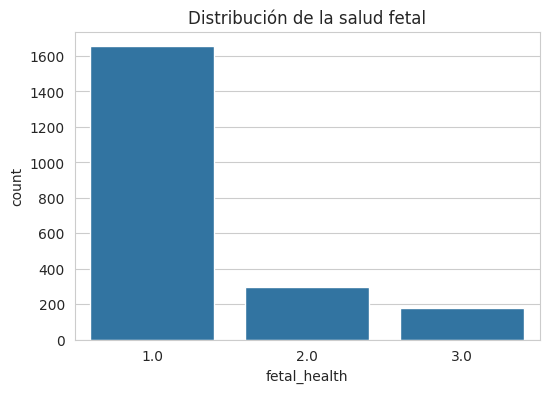

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="fetal_health"
)

plt.title("Distribución de la salud fetal")
plt.show()

**Correlación entre variables numéricas**

In [49]:
corr = df.corr()

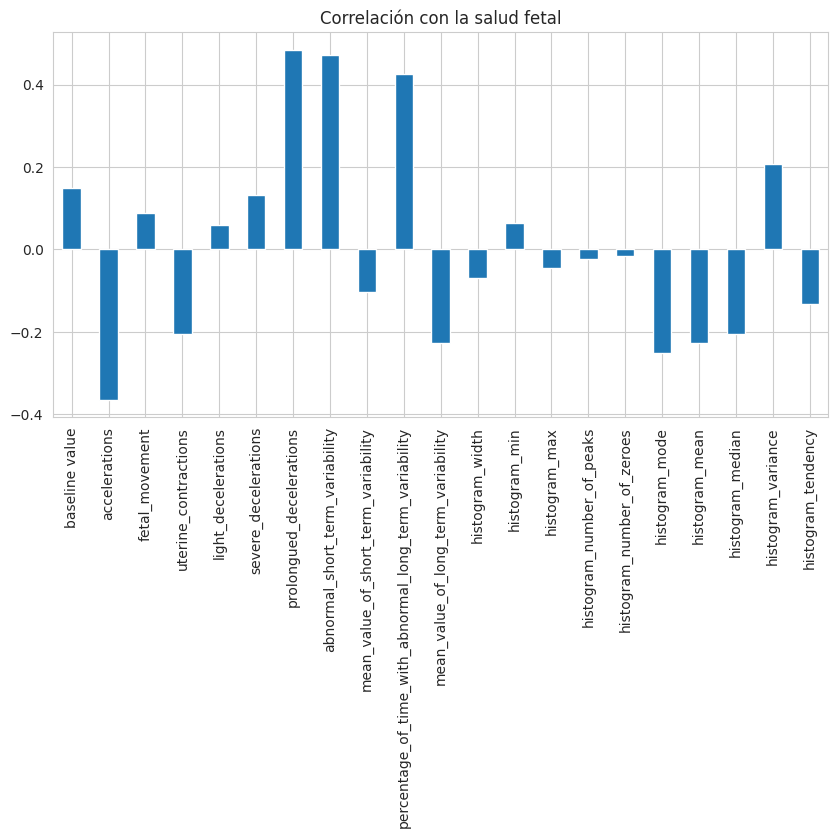

In [50]:
corr_target = corr["fetal_health"]
corr_target.drop("fetal_health").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Correlación con la salud fetal")
plt.show()

El análisis de correlación muestra que algunas variables asociadas a la variabilidad de la frecuencia cardíaca fetal presentan una relación más fuerte con la clasificación de salud fetal. En particular, variables relacionadas con la variabilidad anormal y las desaceleraciones muestran asociaciones más relevantes con la variable objetivo, lo que sugiere que podrían tener una mayor capacidad predictiva en futuros modelos de clasificación.

# **Visualizaciones del Análisis Exploratorio**

**Distribución de Variables Numéricas**

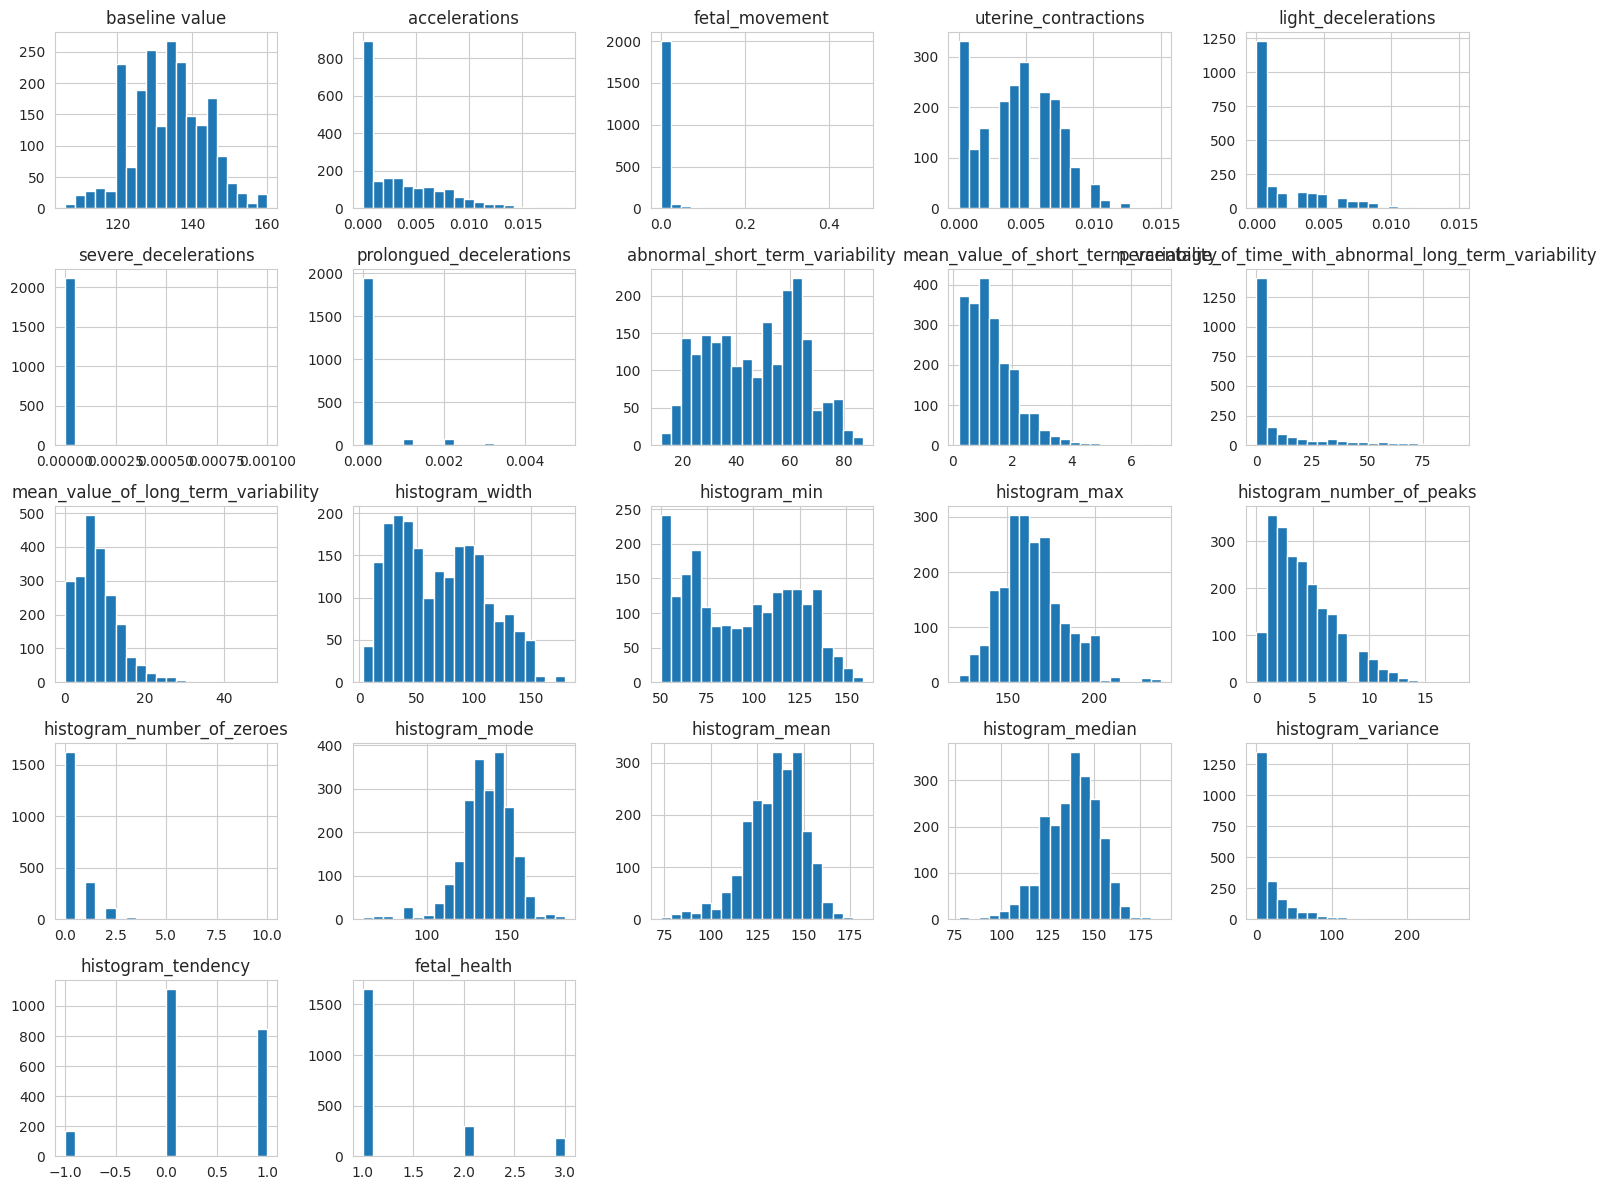

In [47]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

**Identificando Outliers**

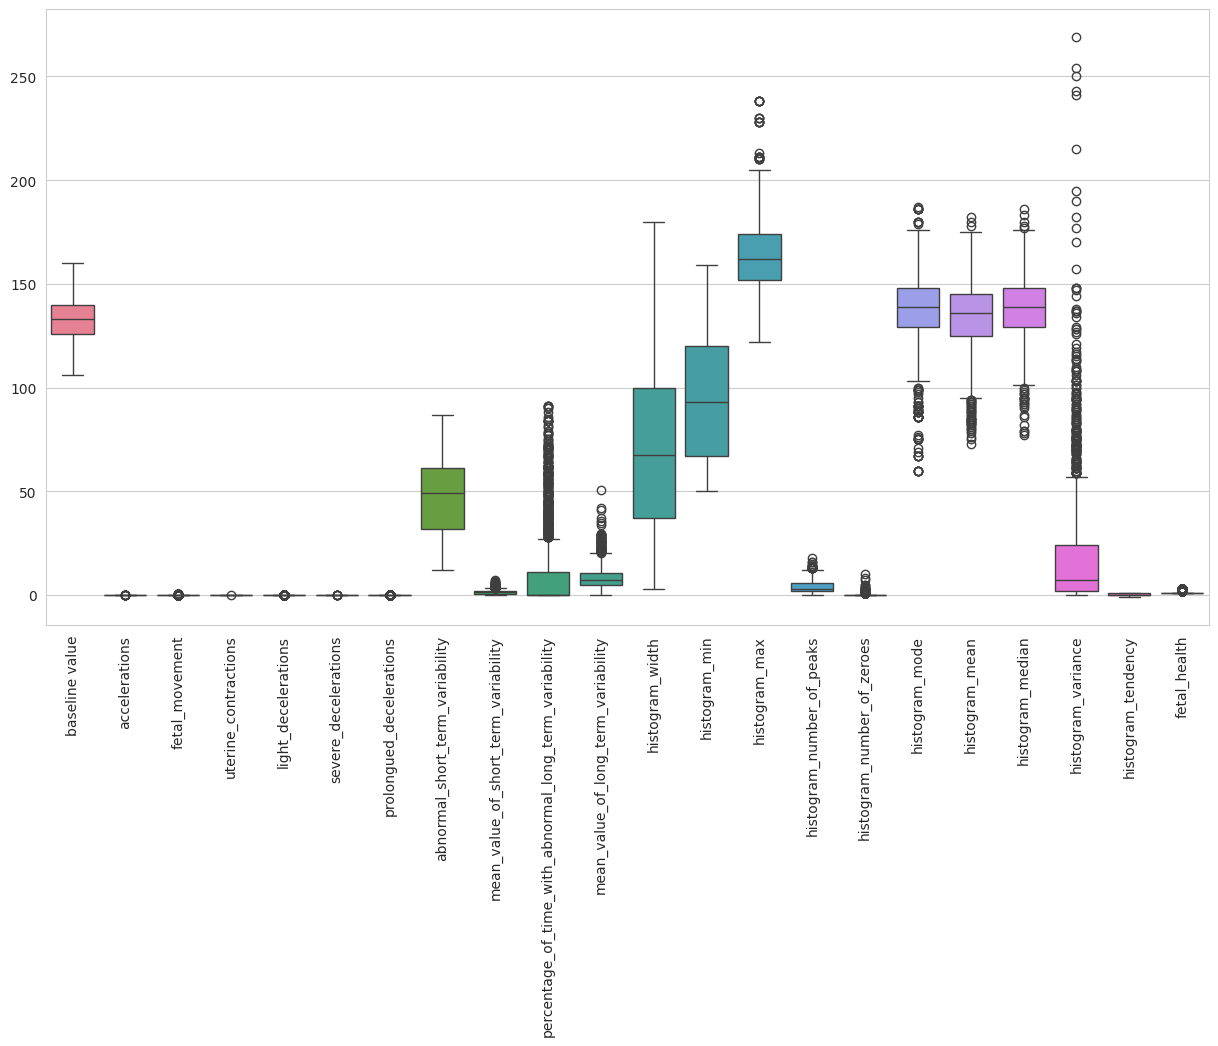

In [51]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.show()

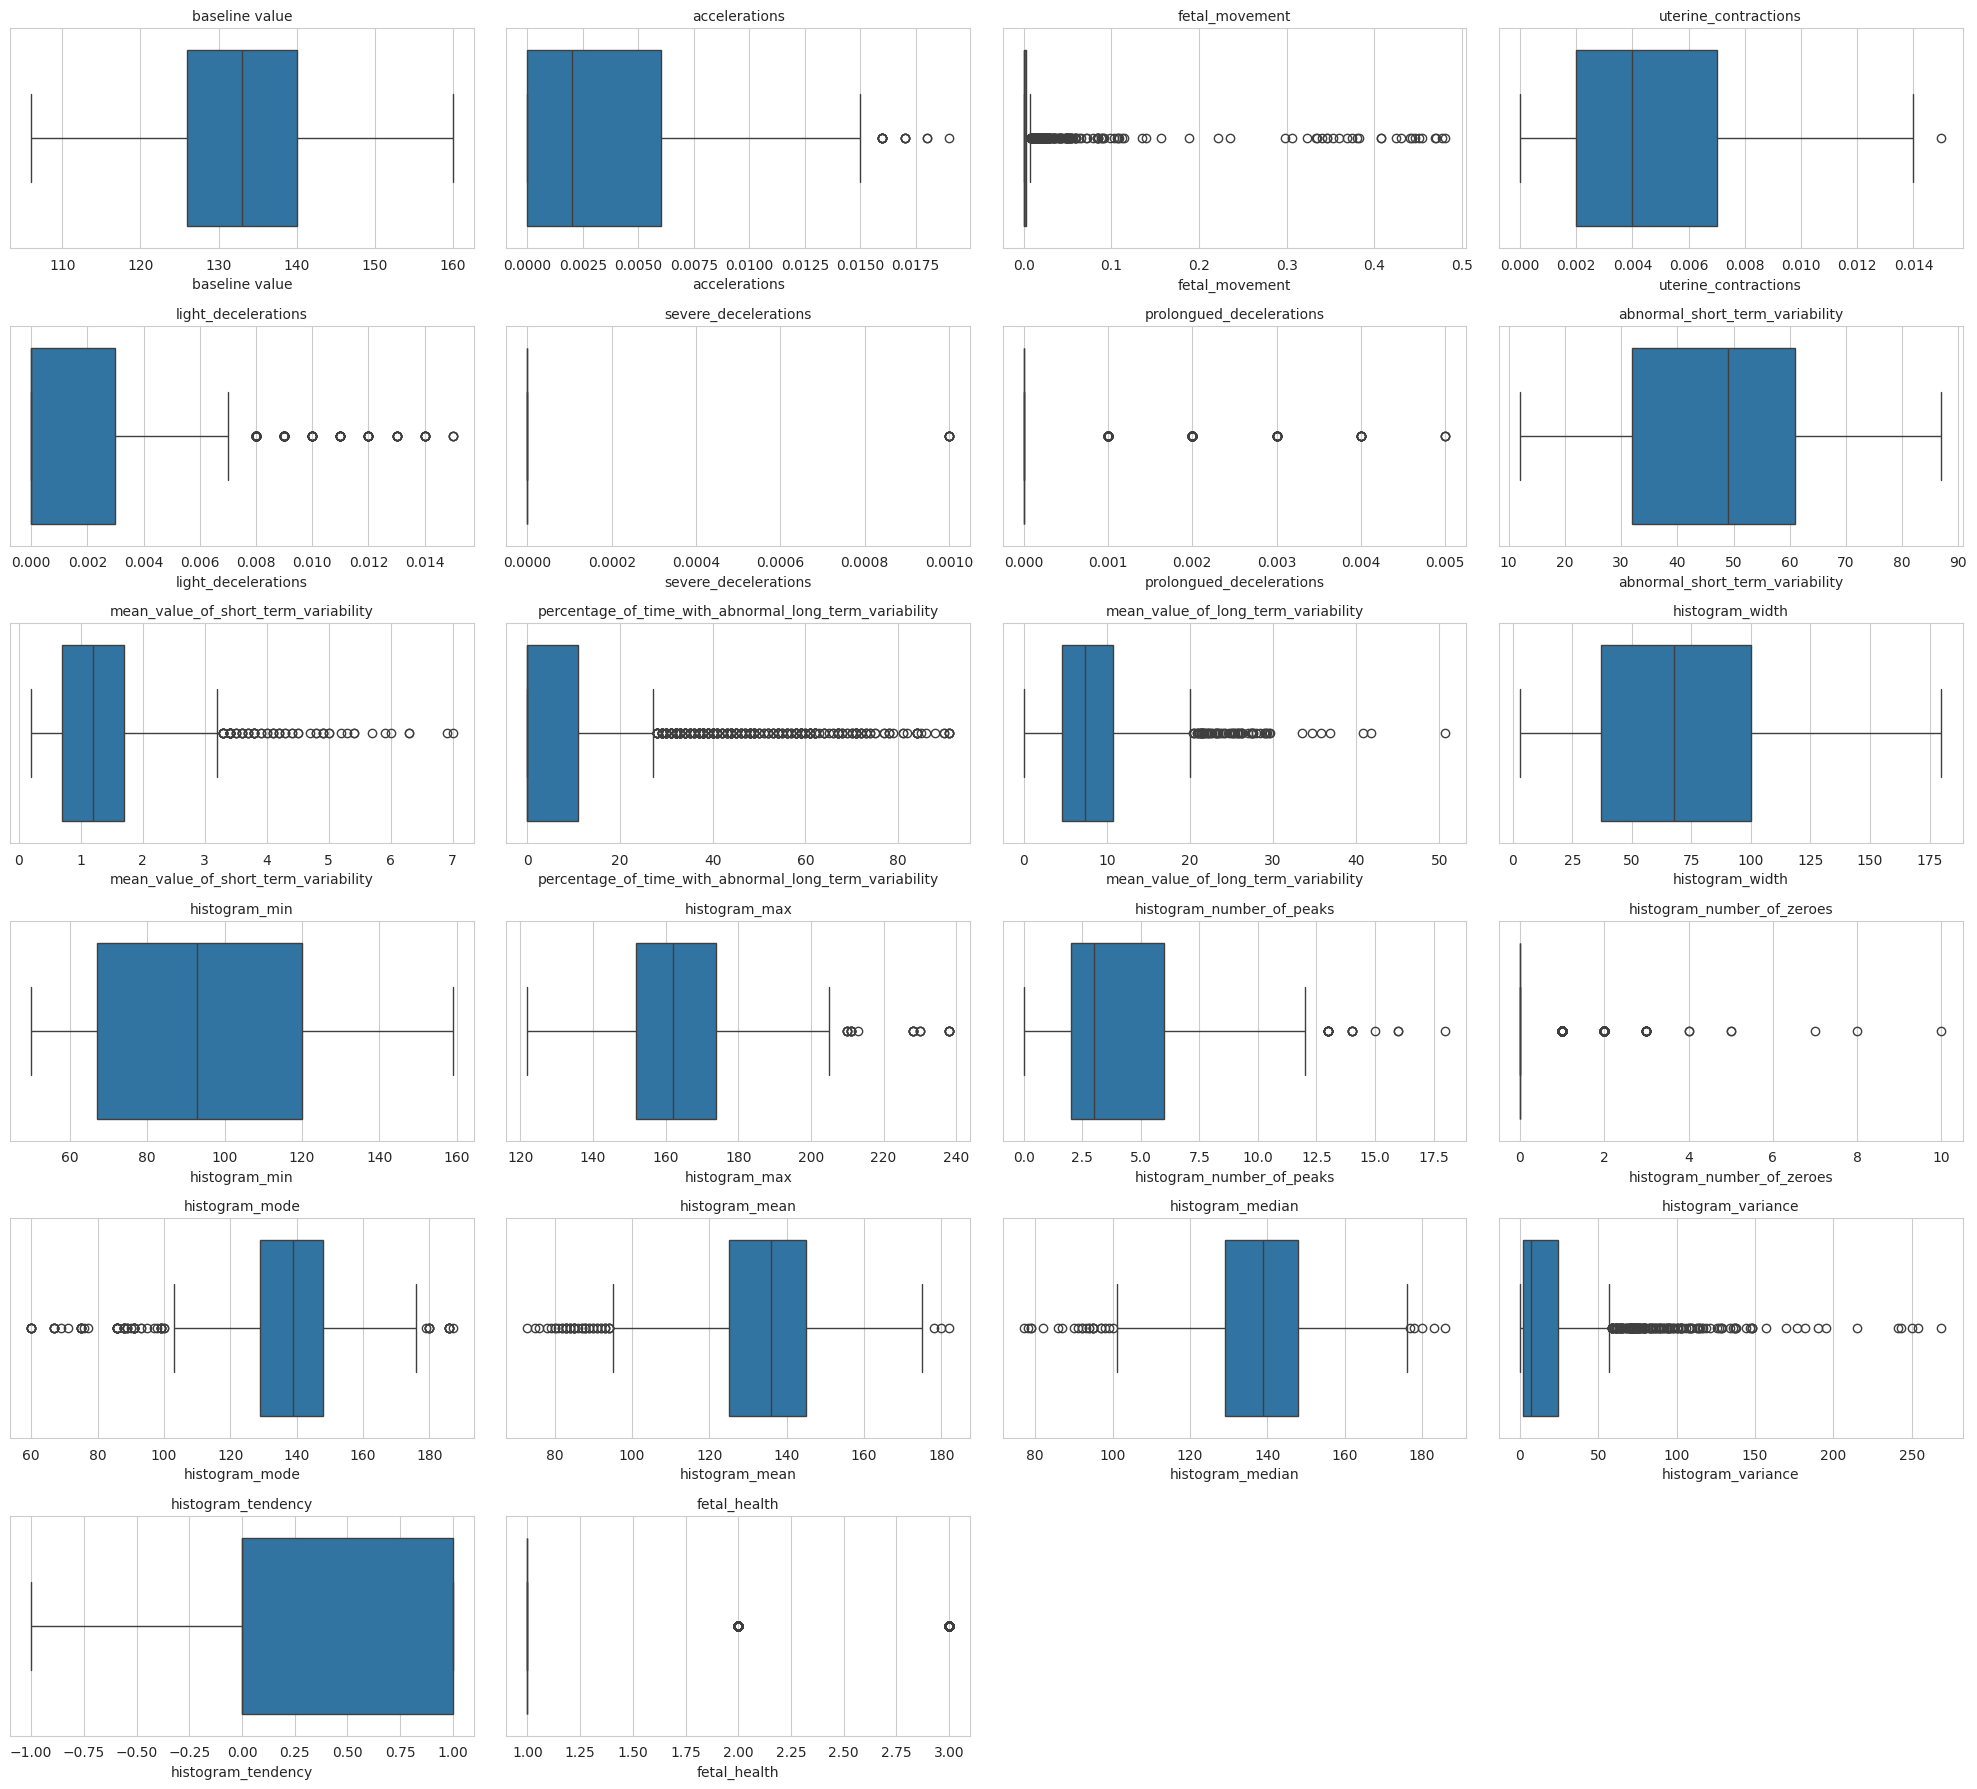

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

n_cols = 4  # cantidad de gráficos por fila
n_rows = int(np.ceil(len(df.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*3))

axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Los diagramas de caja muestran la presencia de valores atípicos en varias variables del conjunto de datos. Sin embargo, a diferencia de otros datasets clínicos, los valores extremos observados no necesariamente representan errores de registro, sino que podrían corresponder a condiciones fisiológicas o patológicas reales detectadas durante el monitoreo fetal.

Las variables fetal_movement, accelerations, light_decelerations, mean_value_of_short_term_variability y percentage_of_time_with_abnormal_long_term_variability presentan una cantidad considerable de observaciones fuera del rango intercuartílico. Esto indica una distribución asimétrica donde la mayoría de los registros se concentra en valores bajos, mientras que un grupo reducido presenta valores significativamente mayores.

Por otro lado, variables como baseline value, abnormal_short_term_variability, histogram_width e histogram_min muestran distribuciones más estables y menor presencia de valores extremos.

En términos generales, los valores atípicos observados parecen ser coherentes con la naturaleza clínica del problema y podrían contener información relevante para la clasificación del estado de salud fetal. Por esta razón, no se recomienda eliminarlos automáticamente sin una evaluación previa de su impacto en los modelos predictivos.

# **Conclusiones del Análisis Exploratorio**

El análisis exploratorio realizado sobre el conjunto de datos Fetal Health permitió obtener una comprensión general de su estructura, calidad y características principales antes de avanzar hacia etapas de modelamiento. En primer lugar, se constató que el dataset posee 2.126 registros y 22 variables completamente numéricas, lo que facilita su procesamiento y análisis. Además, no se identificaron valores nulos, por lo que no será necesario aplicar técnicas de imputación, representando una ventaja importante respecto de otros conjuntos de datos que requieren tratamientos adicionales para completar información faltante.

Desde el punto de vista de la calidad de los datos, se detectó una cantidad reducida de registros duplicados, los cuales deberán ser evaluados en etapas posteriores para determinar si corresponde eliminarlos. Asimismo, la revisión de las estadísticas descriptivas evidenció que las variables presentan rangos coherentes con la naturaleza clínica del monitoreo fetal, aunque existen diferencias importantes en sus escalas de medición y distribuciones.

Las visualizaciones permitieron identificar que muchas variables presentan distribuciones asimétricas y concentraciones importantes de observaciones en valores bajos, situación frecuente en registros clínicos donde ciertos eventos ocurren con menor frecuencia. Del mismo modo, los diagramas de caja mostraron la existencia de valores atípicos en diversas variables. Sin embargo, estos no necesariamente representan errores de registro, ya que podrían corresponder a condiciones fisiológicas o patológicas reales que resultan relevantes para la clasificación del estado de salud fetal.

Finalmente, el análisis de la variable objetivo evidenció un predominio de casos clasificados como normales respecto de las categorías sospechoso y patológico, lo que sugiere la presencia de un desbalance de clases que deberá ser considerado durante el entrenamiento y evaluación de los modelos de clasificación. En conjunto, los resultados obtenidos indican que el dataset presenta una adecuada calidad para el desarrollo de modelos predictivos orientados a la clasificación del estado de salud fetal, constituyendo una base sólida para las siguientes etapas del proyecto.